[INFO] Device : cuda
[INFO] Patient : BraTS20_Training_001
[INFO] Coupe auto : #67
[INFO] Image 240×240 | Classes GT : [0 1 2 3]
  [Niveau 1] fond=1 œdème=2 cœur=0 | FLAIR=[0.447 0.299 0.728] T1ce=[0.547 0.412 0.233]
  Cœur tumoral : 1483 px
  [Niveau 2] T1ce nécrose=0.258 rehausse=0.787

  ── RÉSULTATS (GMM hiérarchique) ──────────────────
  Nécrose=0.000  Œdème=0.807  Rehausse=0.871  (moy 0.559)
  WT=0.880  TC=0.561  ET=0.871

[§ PINN] Lissage de φ (500 ép.)…
  Ép   1/500  MSE=2.27705
  Ép 100/500  MSE=0.03232
  Ép 200/500  MSE=0.02487
  Ép 300/500  MSE=0.01984
  Ép 400/500  MSE=0.01687
  Ép 500/500  MSE=0.01441
  [φ seuillé] WT=0.884  TC=0.604  ET=0.812
[INFO] Figure → /kaggle/working/pipeline_B_gmm.png


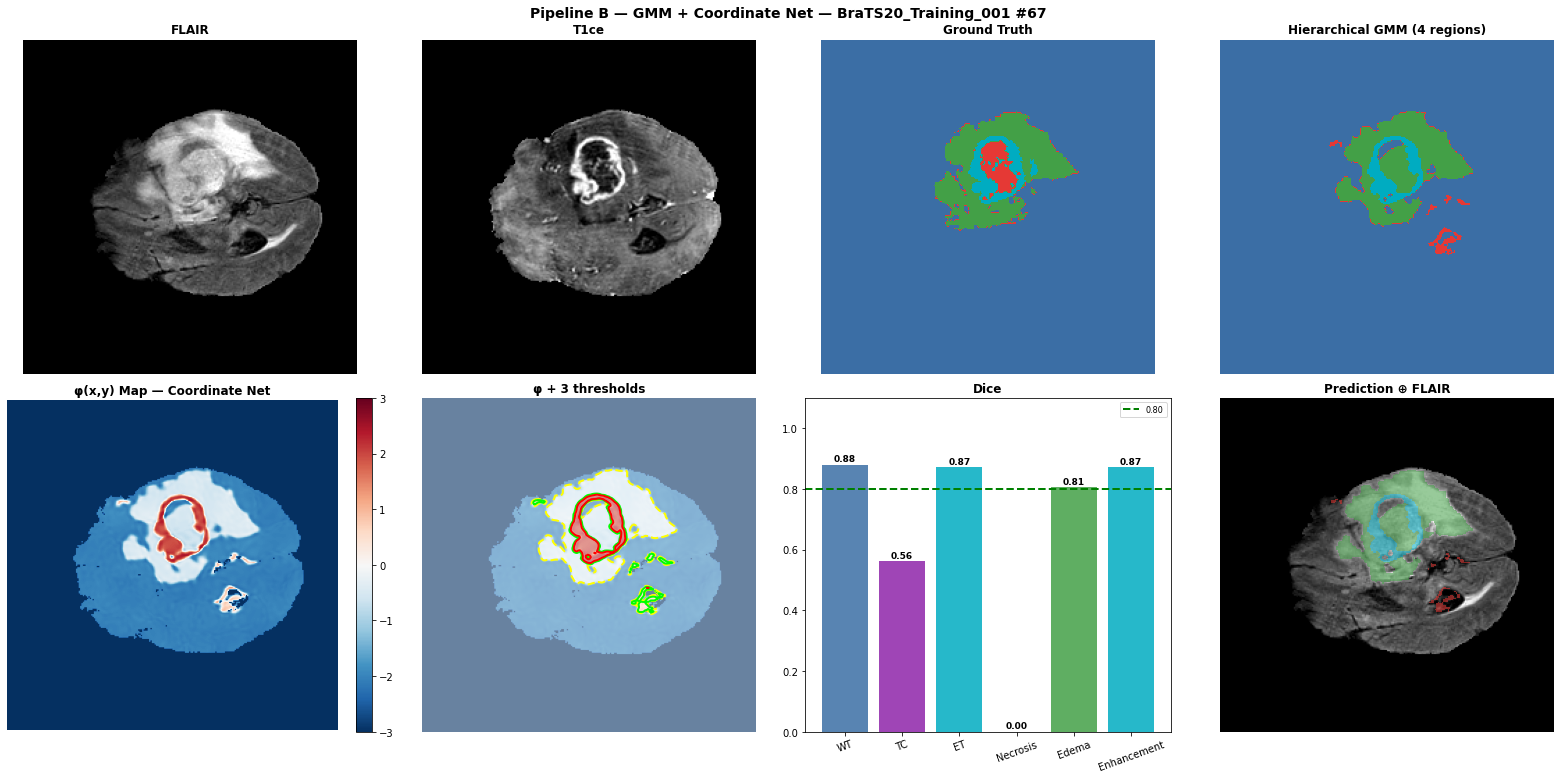

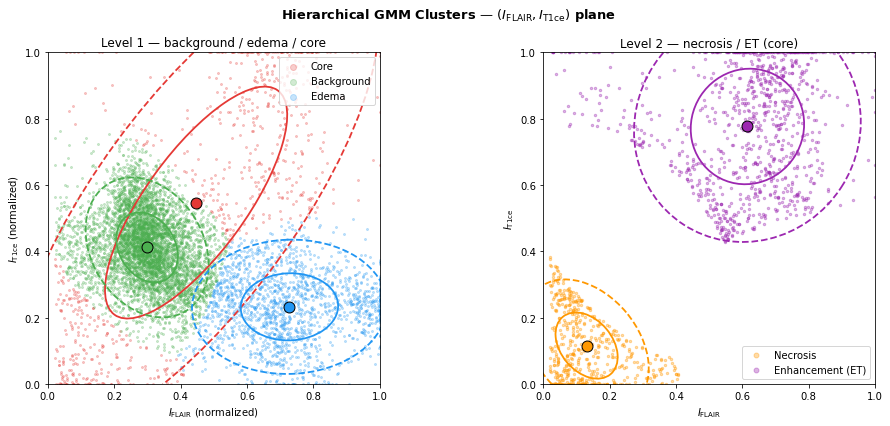

[INFO] → /kaggle/working/fig_gmm_clusters_IFL_IT1.png


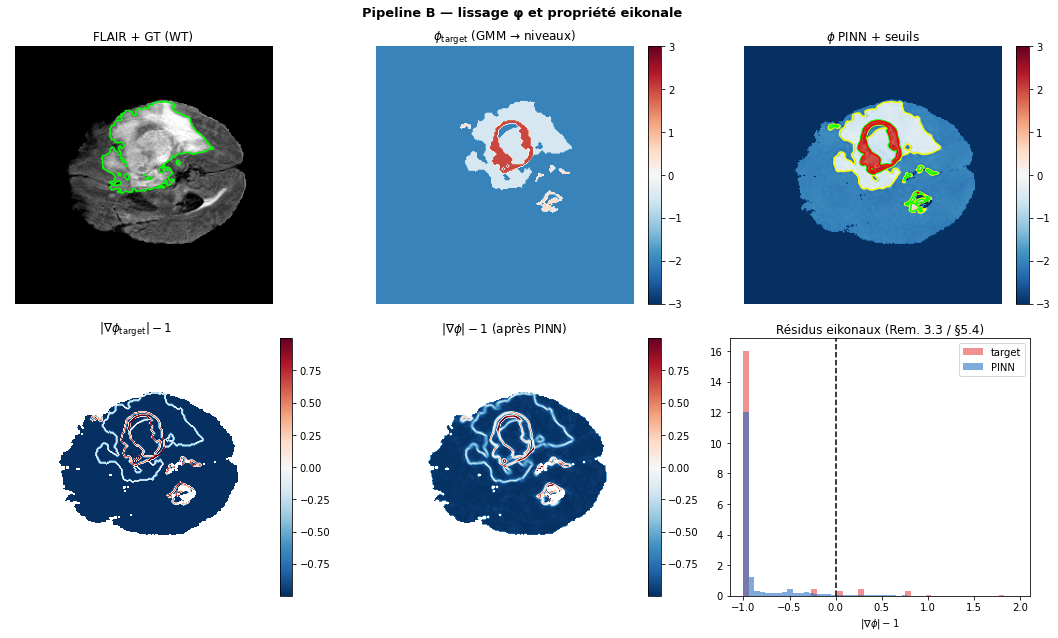

[INFO] → /kaggle/working/fig_eikonal_pipelineB.png


In [16]:
"""
╔══════════════════════════════════════════════════════════════════════════╗
║  PIPELINE B     ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse, FancyBboxPatch
from pathlib import Path

try:
    import nibabel as nib
    HAS_NIBABEL = True
except ImportError:
    HAS_NIBABEL = False

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

try:
    from scipy.ndimage import (
        median_filter, binary_fill_holes, binary_closing, label as cc_label
    )
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

PI = 3.141592653589793
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device : {device}")

DATA_DIR = ("/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

config = {
    "patient_id": None,
    "slice_idx": None,
    "use_position": True,
    "use_pinn": True,
    "phi_scale": 3.0,
    "fourier_scale": 4.0,
    "hidden": [128, 256, 256, 128],
    "fourier_dim": 32,
    "epochs": 500,
    "lr": 1e-3,
    "batch_size": 8192,
    "n_points": 60000,
    "s1": -1.25,
    "s2": 0.0,
    "s3": 1.25,
}

# ═══════════════════════════════════════════════════════════
# §1  CHARGEMENT
# ═══════════════════════════════════════════════════════════

def map_labels(seg):
    m = np.zeros_like(seg, np.int32)
    m[seg == 1] = 1
    m[seg == 2] = 2
    m[seg == 4] = 3
    return m


def find_best_slice(seg_vol):
    bi, bs = seg_vol.shape[2] // 2, -1
    for idx in range(seg_vol.shape[2]):
        sl = seg_vol[:, :, idx]
        n = len([c for c in np.unique(sl) if c in (1, 2, 4)])
        s = n * 100000 + (sl > 0).sum()
        if n >= 3 and s > bs:
            bs, bi = s, idx
    return bi


def load_brats(data_dir, patient_id=None, slice_idx=None):
    if not HAS_NIBABEL:
        raise ImportError("pip install nibabel")
    dp = Path(data_dir)
    pats = sorted([d for d in dp.iterdir() if d.is_dir()])
    path = (dp / patient_id) if patient_id else pats[0]
    name = path.name
    print(f"[INFO] Patient : {name}")

    def ff(s):
        for e in [".nii.gz", ".nii"]:
            f = path / f"{name}_{s}{e}"
            if f.exists():
                return str(f)
        raise FileNotFoundError(s)

    fl = nib.load(ff("flair")).get_fdata()
    tc = nib.load(ff("t1ce")).get_fdata()
    sg = nib.load(ff("seg")).get_fdata().astype(np.int32)

    if slice_idx is None:
        slice_idx = find_best_slice(sg)
        print(f"[INFO] Coupe auto : #{slice_idx}")

    def nm(img):
        b = img[img > 0]
        if len(b) == 0:
            return img.astype(np.float32)
        lo, hi = np.percentile(b, [1, 99])
        return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)

    return (
        nm(fl[:, :, slice_idx]),
        nm(tc[:, :, slice_idx]),
        map_labels(sg[:, :, slice_idx]),
        slice_idx,
        name,
    )


# ═══════════════════════════════════════════════════════════
# §1bis  MÉTRIQUES
# ═══════════════════════════════════════════════════════════

def dice_multi(pred, gt):
    sc = []
    for c in [1, 2, 3]:
        p = pred == c
        g = gt == c
        i = (p & g).sum()
        d = p.sum() + g.sum()
        sc.append(1.0 if d < 1e-8 else 2.0 * i / d)
    return sc, float(np.mean(sc))


def _dice_bin(p, g):
    i = (p & g).sum()
    d = p.sum() + g.sum()
    return 1.0 if d < 1e-8 else 2.0 * i / d


def dice_regions(pred, gt):
    return {
        "WT": _dice_bin(pred > 0, gt > 0),
        "TC": _dice_bin((pred == 1) | (pred == 3), (gt == 1) | (gt == 3)),
        "ET": _dice_bin(pred == 3, gt == 3),
    }


# ═══════════════════════════════════════════════════════════
# §2  GMM HIÉRARCHIQUE
# ═══════════════════════════════════════════════════════════

def build_features(flair, t1ce, coords, use_position=True):
    H, W = flair.shape
    feats = [flair[coords], t1ce[coords]]
    if use_position:
        ys, xs = coords
        feats.append((xs - xs.mean()) / W)
        feats.append((ys - ys.mean()) / H)
    return np.stack(feats, axis=1).astype(np.float32)


def gmm_hierarchique(flair, t1ce, brain_mask, cfg):
    H, W = flair.shape
    coords = np.where(brain_mask)

    X1 = np.stack([flair[coords], t1ce[coords]], 1)
    X1s = StandardScaler().fit_transform(X1)
    gmm1 = GaussianMixture(
        n_components=3, covariance_type="full",
        random_state=42, n_init=10, max_iter=400,
    )
    lab1 = gmm1.fit_predict(X1s)
    seg_l1 = np.full((H, W), -1, np.int32)
    seg_l1[coords] = lab1

    mflair = np.array([flair[coords][lab1 == k].mean() for k in range(3)])
    mt1ce = np.array([t1ce[coords][lab1 == k].mean() for k in range(3)])
    bg = int(np.argmin(mflair))
    rest = [k for k in range(3) if k != bg]
    core_k = rest[int(np.argmax([mt1ce[k] for k in rest]))]
    edema_k = [k for k in rest if k != core_k][0]
    print(
        f"  [Niveau 1] fond={bg} œdème={edema_k} cœur={core_k} | "
        f"FLAIR={np.round(mflair, 3)} T1ce={np.round(mt1ce, 3)}"
    )

    seg = np.zeros((H, W), np.int32)
    seg[seg_l1 == edema_k] = 2
    seg[seg_l1 == core_k] = 99
    print(f"  Cœur tumoral : {(seg == 99).sum()} px")

    core_mask = seg == 99
    if core_mask.sum() > 20:
        ccoords = np.where(core_mask)
        X2 = build_features(flair, t1ce, ccoords, cfg["use_position"])
        X2s = StandardScaler().fit_transform(X2)
        gmm2 = GaussianMixture(
            n_components=2, covariance_type="full",
            random_state=42, n_init=10, max_iter=400,
        )
        lab2 = gmm2.fit_predict(X2s)
        m_t1ce = [X2[lab2 == c, 1].mean() for c in range(2)]
        enh = int(np.argmax(m_t1ce))
        nec = 1 - enh
        print(f"  [Niveau 2] T1ce nécrose={m_t1ce[nec]:.3f} rehausse={m_t1ce[enh]:.3f}")
        seg[ccoords] = np.where(lab2 == nec, 1, 3)
    else:
        seg[core_mask] = 3

    seg[~brain_mask] = 0
    return seg


# ═══════════════════════════════════════════════════════════
# §3  POSTPROCESS
# ═══════════════════════════════════════════════════════════

def postprocess(seg, brain_mask):
    if not HAS_SCIPY:
        return seg
    out = median_filter(seg, size=3)
    out[~brain_mask] = 0
    for c in [1, 2, 3]:
        mask = out == c
        if mask.sum() == 0:
            continue
        lab, n = cc_label(mask)
        sizes = (
            np.array([(lab == i).sum() for i in range(1, n + 1)]) if n else np.array([])
        )
        min_size = max(5, int(0.05 * mask.sum()))
        keep = np.zeros_like(mask)
        for i in range(1, n + 1):
            if sizes[i - 1] >= min_size:
                keep |= lab == i
        keep = binary_closing(keep, iterations=1)
        out[mask & ~keep] = 0
        out[keep] = c
    out[~brain_mask] = 0
    return out


# ═══════════════════════════════════════════════════════════
# §4  PINN φ
# ═══════════════════════════════════════════════════════════

_PHI_LEVELS = {0: -2.0, 2: -0.5, 1: +0.5, 3: +2.0}


def seg_to_phi_target(seg):
    phi = np.full(seg.shape, -2.5, np.float32)
    for l, v in _PHI_LEVELS.items():
        phi[seg == l] = v
    return phi


def phi_to_4regions(phi, brain_mask, s1, s2, s3):
    r = np.zeros_like(phi, np.int32)
    r[(phi >= s1) & (phi < s2)] = 2
    r[(phi >= s2) & (phi < s3)] = 1
    r[phi >= s3] = 3
    r[~brain_mask] = 0
    return r


class PhiNet(nn.Module):
    def __init__(self, hd, fd, fs, ps):
        super().__init__()
        self.phi_scale = ps
        self.register_buffer("B", torch.randn(2, fd) * fs)
        d = fd * 2
        layers = []
        for h in hd:
            layers += [nn.Linear(d, h), nn.Tanh()]
            d = h
        layers += [nn.Linear(d, 1)]
        self.mlp = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xy):
        p = 2 * PI * xy @ self.B
        return self.phi_scale * torch.tanh(
            self.mlp(torch.cat([torch.sin(p), torch.cos(p)], -1))
        )


class PhiDataset(Dataset):
    def __init__(self, phi_target, n_points):
        H, W = phi_target.shape
        rng = np.random.default_rng(42)
        xs = rng.uniform(0, 1, n_points).astype(np.float32)
        ys = rng.uniform(0, 1, n_points).astype(np.float32)
        px = (xs * (W - 1)).astype(int)
        py = (ys * (H - 1)).astype(int)
        self.pts = torch.from_numpy(np.stack([xs, ys], 1))
        self.phi = torch.from_numpy(phi_target[py, px])

    def __len__(self):
        return len(self.pts)

    def __getitem__(self, i):
        return self.pts[i], self.phi[i]


def train_phi(model, ds, cfg):
    opt = optim.Adam(model.parameters(), lr=cfg["lr"])
    dl = DataLoader(ds, batch_size=cfg["batch_size"], shuffle=True)
    print(f"\n[§ PINN] Lissage de φ ({cfg['epochs']} ép.)…")
    for ep in range(1, cfg["epochs"] + 1):
        tot = 0.0
        for pts, phi_t in dl:
            pts, phi_t = pts.to(device), phi_t.to(device)
            loss = ((model(pts).squeeze() - phi_t) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()
        if ep % 100 == 0 or ep == 1:
            print(f"  Ép {ep:3d}/{cfg['epochs']}  MSE={tot / len(dl):.5f}")


@torch.no_grad()
def build_phi_map(model, H, W):
    ys = np.linspace(0, 1, H, dtype=np.float32)
    xs = np.linspace(0, 1, W, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")
    pts = torch.from_numpy(np.stack([xx.ravel(), yy.ravel()], 1)).to(device)
    return model(pts).cpu().numpy().reshape(H, W)


# ═══════════════════════════════════════════════════════════
# §5  VISUALISATION PIPELINE
# ═══════════════════════════════════════════════════════════

def visualize(flair, t1ce, gt, seg, phi, sub, reg, name, slice_idx, save):
    cmap4 = ListedColormap(["#3b6ea5", "#E53935", "#43A047", "#00ACC1"])
    fig, ax = plt.subplots(2, 4, figsize=(22, 11))

    ax[0, 0].imshow(flair, cmap="gray")
    ax[0, 0].set_title("FLAIR", fontweight="bold")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(t1ce, cmap="gray")
    ax[0, 1].set_title("T1ce", fontweight="bold")
    ax[0, 1].axis("off")

    ax[0, 2].imshow(gt, cmap=cmap4, vmin=0, vmax=3)
    ax[0, 2].set_title("Ground Truth", fontweight="bold")
    ax[0, 2].axis("off")

    ax[0, 3].imshow(seg, cmap=cmap4, vmin=0, vmax=3)
    ax[0, 3].set_title("Hierarchical GMM (4 regions)", fontweight="bold")
    ax[0, 3].axis("off")

    im = ax[1, 0].imshow(phi, cmap="RdBu_r", vmin=-3, vmax=3)
    ax[1, 0].set_title("φ(x,y) Map — Coordinate Net", fontweight="bold")
    ax[1, 0].axis("off")
    plt.colorbar(im, ax=ax[1, 0], fraction=0.046)

    ax[1, 1].imshow(phi, cmap="RdBu_r", vmin=-3, vmax=3, alpha=0.6)
    for s, col in zip(
        [config["s1"], config["s2"], config["s3"]], ["yellow", "lime", "red"]
    ):
        try:
            ax[1, 1].contour(phi, levels=[s], colors=[col], linewidths=2)
        except Exception:
            pass
    ax[1, 1].set_title("φ + 3 thresholds", fontweight="bold")
    ax[1, 1].axis("off")

    names = ["WT", "TC", "ET", "Necrosis", "Edema", "Enhancement"]
    vals = [reg["WT"], reg["TC"], reg["ET"], sub[0], sub[1], sub[2]]
    cols = ["#3b6ea5", "#8E24AA", "#00ACC1", "#E53935", "#43A047", "#00ACC1"]
    bars = ax[1, 2].bar(names, vals, color=cols, alpha=0.85)
    ax[1, 2].axhline(0.80, color="green", lw=2, ls="--", label="0.80")
    for b, d in zip(bars, vals):
        ax[1, 2].text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.01,
            f"{d:.2f}",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )
    ax[1, 2].set_ylim(0, 1.1)
    ax[1, 2].legend(fontsize=8)
    ax[1, 2].tick_params(axis="x", labelrotation=20)
    ax[1, 2].set_title("Dice", fontweight="bold")

    ax[1, 3].imshow(flair, cmap="gray")
    m = np.ma.masked_where(seg == 0, seg)
    ax[1, 3].imshow(m, cmap=cmap4, vmin=0, vmax=3, alpha=0.55)
    ax[1, 3].set_title("Prediction ⊕ FLAIR", fontweight="bold")
    ax[1, 3].axis("off")

    fig.suptitle(
        f"Pipeline B — GMM + Coordinate Net — {name} #{slice_idx}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    try:
        plt.savefig(save, dpi=150)
        print(f"[INFO] Figure → {save}")
    except Exception as e:
        print(f"[WARN] {e}")
    plt.show()
    plt.close(fig)


# ═══════════════════════════════════════════════════════════
# §6  MAIN
# ═══════════════════════════════════════════════════════════

def main():
    SAVE = "/kaggle/working/pipeline_B_gmm.png"
    flair, t1ce, gt, slice_idx, name = load_brats(
        DATA_DIR, config["patient_id"], config["slice_idx"]
    )
    brain_mask = flair > 0.02
    H, W = flair.shape
    print(f"[INFO] Image {H}×{W} | Classes GT : {np.unique(gt)}")

    seg = gmm_hierarchique(flair, t1ce, brain_mask, config)
    seg = postprocess(seg, brain_mask)
    sub, md = dice_multi(seg, gt)
    reg = dice_regions(seg, gt)
    print("\n  ── RÉSULTATS (GMM hiérarchique) ──────────────────")
    print(
        f"  Nécrose={sub[0]:.3f}  Œdème={sub[1]:.3f}  "
        f"Rehausse={sub[2]:.3f}  (moy {md:.3f})"
    )
    print(f"  WT={reg['WT']:.3f}  TC={reg['TC']:.3f}  ET={reg['ET']:.3f}")

    if config["use_pinn"]:
        phi_t = seg_to_phi_target(seg)
        net = PhiNet(
            config["hidden"],
            config["fourier_dim"],
            config["fourier_scale"],
            config["phi_scale"],
        ).to(device)
        train_phi(net, PhiDataset(phi_t, config["n_points"]), config)
        phi = build_phi_map(net, H, W)
        phi[~brain_mask] = -3.0
        seg_phi = phi_to_4regions(
            phi, brain_mask, config["s1"], config["s2"], config["s3"]
        )
        rphi = dice_regions(seg_phi, gt)
        print(
            f"  [φ seuillé] WT={rphi['WT']:.3f}  "
            f"TC={rphi['TC']:.3f}  ET={rphi['ET']:.3f}"
        )
    else:
        phi = seg_to_phi_target(seg)
        phi_t = phi

    visualize(flair, t1ce, gt, seg, phi, sub, reg, name, slice_idx, SAVE)
    return seg, phi, phi_t if config["use_pinn"] else phi, flair, t1ce, gt, brain_mask, name, slice_idx


# ═══════════════════════════════════════════════════════════
# §7  FIGURES — définitions
# ═══════════════════════════════════════════════════════════

def _box(ax, xy, w, h, text, fc="#E3F2FD", ec="#1565C0"):
    box = FancyBboxPatch(
        xy, w, h,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        facecolor=fc, edgecolor=ec, linewidth=1.8,
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + w / 2, xy[1] + h / 2, text,
        ha="center", va="center", fontsize=9, fontweight="bold",
    )


def _arrow(ax, start, end):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", color="#333", lw=1.6),
    )


def plot_gmm_intensity_plane(
    flair, t1ce, brain_mask,
    save="/kaggle/working/fig_gmm_clusters_IFL_IT1.png",
):
    """Same intensity assignment as hierarchical_gmm + 1σ/2σ ellipses."""
    pts = np.column_stack([flair[brain_mask], t1ce[brain_mask]])
    Xs = StandardScaler().fit_transform(pts)

    gmm1 = GaussianMixture(
        n_components=3, covariance_type="full",
        random_state=42, n_init=10, max_iter=400,
    ).fit(Xs)
    lab1 = gmm1.predict(Xs)

    mfl = np.array([pts[lab1 == k, 0].mean() for k in range(3)])
    mt1 = np.array([pts[lab1 == k, 1].mean() for k in range(3)])
    bg = int(np.argmin(mfl))
    rest = [k for k in range(3) if k != bg]
    core_k = rest[int(np.argmax([mt1[k] for k in rest]))]
    edema_k = [k for k in rest if k != core_k][0]

    names = {bg: "Background", edema_k: "Edema", core_k: "Core"}
    colors = {bg: "#4CAF50", edema_k: "#2196F3", core_k: "#E53935"}

    means_raw = np.array([pts[lab1 == k].mean(0) for k in range(3)])
    covs_raw = [np.cov(pts[lab1 == k].T) for k in range(3)]

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    rng = np.random.default_rng(0)
    idx = rng.choice(len(pts), size=min(8000, len(pts)), replace=False)

    for k in range(3):
        m = lab1[idx] == k
        ax[0].scatter(
            pts[idx][m, 0], pts[idx][m, 1],
            s=4, alpha=0.25, c=colors[k], label=names[k],
        )
        ax[0].scatter(*means_raw[k], s=120, c=colors[k], edgecolors="k", zorder=5)
        for nsig, ls in [(1, "-"), (2, "--")]:
            vals, vecs = np.linalg.eigh(covs_raw[k])
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            w, h = 2 * nsig * np.sqrt(np.maximum(vals, 1e-12))
            ax[0].add_patch(
                Ellipse(
                    means_raw[k], w, h, angle=theta,
                    fill=False, edgecolor=colors[k], lw=1.8, ls=ls,
                )
            )
    ax[0].set_xlabel(r"$I_{\mathrm{FLAIR}}$ (normalized)")
    ax[0].set_ylabel(r"$I_{\mathrm{T1ce}}$ (normalized)")
    ax[0].set_title("Level 1 — background / edema / core")
    ax[0].legend(markerscale=3, loc="upper right")
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, 1)
    ax[0].set_aspect("equal")

    core_pts = pts[lab1 == core_k]
    if len(core_pts) > 50:
        X2s = StandardScaler().fit_transform(core_pts)
        gmm2 = GaussianMixture(
            n_components=2, covariance_type="full",
            random_state=42, n_init=10, max_iter=400,
        ).fit(X2s)
        lab2 = gmm2.predict(X2s)
        m_t1 = [core_pts[lab2 == c, 1].mean() for c in range(2)]
        enh_k = int(np.argmax(m_t1))
        nec_k = int(np.argmin(m_t1))
        c2 = {nec_k: "#FF9800", enh_k: "#9C27B0"}
        n2 = {nec_k: "Necrosis", enh_k: "Enhancement (ET)"}
        for k in range(2):
            m = lab2 == k
            ax[1].scatter(
                core_pts[m, 0], core_pts[m, 1],
                s=6, alpha=0.35, c=c2[k], label=n2[k],
            )
            mu = core_pts[lab2 == k].mean(0)
            ax[1].scatter(*mu, s=120, c=c2[k], edgecolors="k", zorder=5)
            cov = np.cov(core_pts[lab2 == k].T)
            for nsig, ls in [(1, "-"), (2, "--")]:
                vals, vecs = np.linalg.eigh(cov)
                order = vals.argsort()[::-1]
                vals, vecs = vals[order], vecs[:, order]
                theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
                w, h = 2 * nsig * np.sqrt(np.maximum(vals, 1e-12))
                ax[1].add_patch(
                    Ellipse(
                        mu, w, h, angle=theta,
                        fill=False, edgecolor=c2[k], lw=1.8, ls=ls,
                    )
                )
        ax[1].legend(markerscale=2)

    ax[1].set_xlabel(r"$I_{\mathrm{FLAIR}}$")
    ax[1].set_ylabel(r"$I_{\mathrm{T1ce}}$")
    ax[1].set_title("Level 2 — necrosis / ET (core)")
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, 1)
    ax[1].set_aspect("equal")

    fig.suptitle(
        r"Hierarchical GMM Clusters — $(I_{\mathrm{FLAIR}}, I_{\mathrm{T1ce}})$ plane",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[INFO] → {save}")


def eikonal_residual(phi, eps=1e-6):
    gy, gx = np.gradient(phi)
    return np.sqrt(gx ** 2 + gy ** 2 + eps) - 1.0


def plot_eikonal_phi(
    flair, phi_target, phi, brain_mask, gt,
    save="/kaggle/working/fig_eikonal_pipelineB.png",
):
    res_t = eikonal_residual(phi_target)
    res_t[~brain_mask] = np.nan
    res_p = eikonal_residual(phi)
    res_p[~brain_mask] = np.nan
    vmax = np.nanpercentile(
        np.abs(np.concatenate([res_t[brain_mask], res_p[brain_mask]])), 98
    )

    fig, ax = plt.subplots(2, 3, figsize=(15, 9))

    ax[0, 0].imshow(flair, cmap="gray")
    ax[0, 0].contour(gt > 0, levels=[0.5], colors=["lime"], linewidths=1.5)
    ax[0, 0].set_title("FLAIR + GT (WT)")
    ax[0, 0].axis("off")

    im = ax[0, 1].imshow(phi_target, cmap="RdBu_r", vmin=-3, vmax=3)
    ax[0, 1].set_title(r"$\phi_{\mathrm{target}}$ (GMM → niveaux)")
    ax[0, 1].axis("off")
    plt.colorbar(im, ax=ax[0, 1], fraction=0.046)

    im = ax[0, 2].imshow(phi, cmap="RdBu_r", vmin=-3, vmax=3)
    ax[0, 2].contour(
        phi,
        levels=[config["s1"], config["s2"], config["s3"]],
        colors=["yellow", "lime", "red"],
        linewidths=1.5,
    )
    ax[0, 2].set_title(r"$\phi$ PINN + seuils")
    ax[0, 2].axis("off")
    plt.colorbar(im, ax=ax[0, 2], fraction=0.046)

    im = ax[1, 0].imshow(res_t, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax[1, 0].set_title(r"$|\nabla\phi_{\mathrm{target}}|-1$")
    ax[1, 0].axis("off")
    plt.colorbar(im, ax=ax[1, 0], fraction=0.046)

    im = ax[1, 1].imshow(res_p, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax[1, 1].set_title(r"$|\nabla\phi|-1$ (après PINN)")
    ax[1, 1].axis("off")
    plt.colorbar(im, ax=ax[1, 1], fraction=0.046)

    ax[1, 2].hist(
        res_t[brain_mask].ravel(), bins=50, alpha=0.55,
        density=True, color="#E53935", label="target",
    )
    ax[1, 2].hist(
        res_p[brain_mask].ravel(), bins=50, alpha=0.55,
        density=True, color="#1565C0", label="PINN",
    )
    ax[1, 2].axvline(0, color="k", ls="--")
    ax[1, 2].legend()
    ax[1, 2].set_title("Résidus eikonaux (Rem. 3.3 / §5.4)")
    ax[1, 2].set_xlabel(r"$|\nabla\phi|-1$")

    fig.suptitle(
        "Pipeline B — lissage φ et propriété eikonale",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[INFO] → {save}")



# ═══════════════════════════════════════════════════════════
# §8  LANCEMENT
# ═══════════════════════════════════════════════════════════

if __name__ == "__main__":
    # 1) Pipeline complet
    seg, phi, phi_t, flair, t1ce, gt, brain_mask, name, slice_idx = main()

    # 2) Figure GMM dans le plan (IFL, IT1)
    plot_gmm_intensity_plane(flair, t1ce, brain_mask)

    # 3) Eikonal avant / après PINN
    if config["use_pinn"]:
        plot_eikonal_phi(flair, phi_t, phi, brain_mask, gt)

   

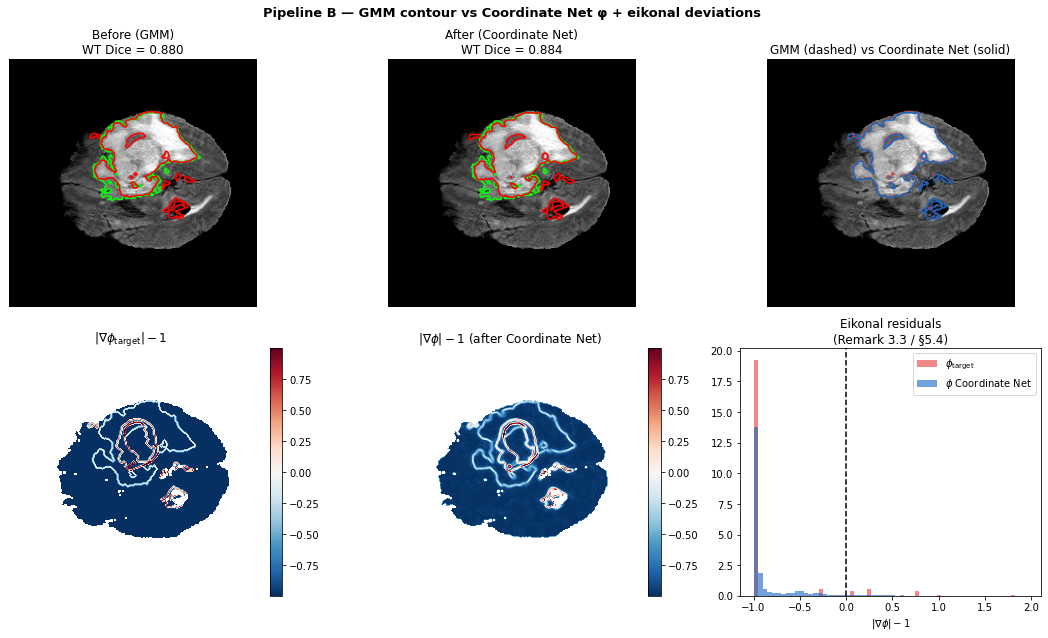

[INFO] Figure saved → fig_refinement.png


In [17]:
def plot_refinement_pipelineB(flair, gt, phi_target, phi, brain_mask, seg_gmm, seg_phi, save="fig_refinement.png"):
    d_before = _dice_bin(seg_gmm > 0, gt > 0)
    d_after  = _dice_bin(seg_phi > 0, gt > 0)
    res0, res1 = eikonal_residual(phi_target), eikonal_residual(phi)
    res0[~brain_mask], res1[~brain_mask] = np.nan, np.nan
    vmax = np.nanpercentile(np.abs(np.concatenate([res0[brain_mask], res1[brain_mask]])), 98)

    fig, ax = plt.subplots(2, 3, figsize=(15, 9))
    ax[0, 0].imshow(flair, cmap="gray"); ax[0, 0].contour(gt > 0, levels=[0.5], colors=["lime"], linewidths=1.5)
    ax[0, 0].contour(seg_gmm > 0, levels=[0.5], colors=["red"], linewidths=1.5)
    ax[0, 0].set_title(f"Before (GMM)\nWT Dice = {d_before:.3f}"); ax[0, 0].axis("off")

    ax[0, 1].imshow(flair, cmap="gray"); ax[0, 1].contour(gt > 0, levels=[0.5], colors=["lime"], linewidths=1.5)
    ax[0, 1].contour(seg_phi > 0, levels=[0.5], colors=["red"], linewidths=1.5)
    ax[0, 1].set_title(f"After (Coordinate Net)\nWT Dice = {d_after:.3f}"); ax[0, 1].axis("off")

    ax[0, 2].imshow(flair, cmap="gray")
    ax[0, 2].contour(seg_gmm > 0, levels=[0.5], colors=["#E53935"], linewidths=1.2, linestyles="--")
    ax[0, 2].contour(seg_phi > 0, levels=[0.5], colors=["#1565C0"], linewidths=1.5)
    ax[0, 2].set_title("GMM (dashed) vs Coordinate Net (solid)"); ax[0, 2].axis("off")

    im0 = ax[1, 0].imshow(res0, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax[1, 0].set_title(r"$|\nabla\phi_{\mathrm{target}}|-1$"); ax[1, 0].axis("off")
    plt.colorbar(im0, ax=ax[1, 0], fraction=0.046)

    im1 = ax[1, 1].imshow(res1, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax[1, 1].set_title(r"$|\nabla\phi|-1$ (after Coordinate Net)"); ax[1, 1].axis("off")
    plt.colorbar(im1, ax=ax[1, 1], fraction=0.046)

    ax[1, 2].hist(res0[brain_mask].ravel(), bins=60, alpha=0.6, density=True, color="#E53935", label=r"$\phi_{\mathrm{target}}$")
    ax[1, 2].hist(res1[brain_mask].ravel(), bins=60, alpha=0.6, density=True, color="#1565C0", label=r"$\phi$ Coordinate Net")
    ax[1, 2].axvline(0, color="k", ls="--"); ax[1, 2].legend()
    ax[1, 2].set_title("Eikonal residuals\n(Remark 3.3 / §5.4)"); ax[1, 2].set_xlabel(r"$|\nabla\phi|-1$")

    fig.suptitle("Pipeline B — GMM contour vs Coordinate Net φ + eikonal deviations", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.savefig(save, dpi=200, bbox_inches="tight"); plt.show()
    print(f"[INFO] Figure saved → {save}")


seg_phi = phi_to_4regions(phi, brain_mask, config["s1"], config["s2"], config["s3"])
plot_refinement_pipelineB(
    flair, gt, phi_t, phi, brain_mask, seg, seg_phi,
)

In [18]:
# =====================================================================
#  MEASUREMENT CELL -- Chapter 5, Table 5.5  (CORRECTED)
#
#  Fixes the argument order in the PhiNet constructor. The signature is
#      PhiNet(hidden, fourier_dim, fourier_scale, phi_scale)
#  i.e. the hidden-layer list comes FIRST. The previous version passed
#  fourier_dim first, so fourier_scale (a float) landed in the fd slot
#  and torch.randn(2, 4.0) raised
#      "type must be tuple of ints, but got float"
#  on every slice. That is why the phi-thresholded row came back empty
#  while the GMM rows were filled: the GMM part never touched PhiNet.
#
#  Run AFTER the Pipeline B cell.
# =====================================================================

import numpy as np
from pathlib import Path

N_PATIENTS = 10           # 10-20 recommended
SLICES_PER_PATIENT = 3    # 3-5
SLICE_STEP = 5            # offset in slices around the auto-selected one

pats = sorted([d for d in Path(DATA_DIR).iterdir() if d.is_dir()])[:N_PATIENTS]
rows = {k: [] for k in ["nec", "oed", "enh", "WT", "TC", "ET", "WTp", "TCp", "ETp"]}
n_ok, n_skip = 0, 0

print(f"[INFO] Evaluating {N_PATIENTS} patients x {SLICES_PER_PATIENT} slices...")
for p in pats:
    # locate the automatically chosen slice once, then step around it
    _, _, _, base_idx, _ = load_brats(DATA_DIR, p.name, None)
    for off in range(SLICES_PER_PATIENT):
        sidx = base_idx + (off - SLICES_PER_PATIENT // 2) * SLICE_STEP
        try:
            fl, t1, g, sidx, nm = load_brats(DATA_DIR, p.name, sidx)
            bm = fl > 0.02
            if g.sum() < 50:
                n_skip += 1
                continue

            # ---- unsupervised segmentation ----
            sg = gmm_hierarchique(fl, t1, bm, config)
            sg = postprocess(sg, bm)
            sub, _ = dice_multi(sg, g)
            reg = dice_regions(sg, g)
            rows["nec"].append(sub[0]); rows["oed"].append(sub[1]); rows["enh"].append(sub[2])
            rows["WT"].append(reg["WT"]); rows["TC"].append(reg["TC"]); rows["ET"].append(reg["ET"])

            # ---- level-set regression (CORRECTED CALL) ----
            pt = seg_to_phi_target(sg)
            net = PhiNet(config["hidden"], config["fourier_dim"],
                         config["fourier_scale"], config["phi_scale"]).to(device)
            train_phi(net, PhiDataset(pt, config["n_points"]), config)
            H, W = fl.shape
            ph = build_phi_map(net, H, W)
            ph[~bm] = -3.0
            sp = phi_to_4regions(ph, bm, config["s1"], config["s2"], config["s3"])
            rp = dice_regions(sp, g)
            rows["WTp"].append(rp["WT"]); rows["TCp"].append(rp["TC"]); rows["ETp"].append(rp["ET"])

            n_ok += 1
            print(f"   {p.name} slice {sidx:3d}: "
                  f"WT {reg['WT']:.3f} -> {rp['WT']:.3f} | "
                  f"TC {reg['TC']:.3f} -> {rp['TC']:.3f} | "
                  f"ET {reg['ET']:.3f} -> {rp['ET']:.3f}")
        except Exception as e:
            n_skip += 1
            print(f"   [skip] {p.name} slice {sidx}: {type(e).__name__}: {e}")


def ms(key):
    v = np.asarray(rows[key], float)
    if v.size < 2:
        return "insufficient data"
    return f"${v.mean():.3f} \\pm {v.std(ddof=1):.3f}$"


def summary(key):
    v = np.asarray(rows[key], float)
    if v.size == 0:
        return "n/a"
    return (f"mean={v.mean():.3f} std={v.std(ddof=1):.3f} "
            f"min={v.min():.3f} max={v.max():.3f} "
            f"median={np.median(v):.3f}")


print("\n" + "=" * 70)
print(f" TABLE 5.5  --  {n_ok} slices evaluated, {n_skip} skipped")
print("=" * 70)
print(f"    Sub-class Dice (GMM) & {ms('nec')} & {ms('oed')} & {ms('enh')} \\\\")
print(f"    Region Dice (GMM)                & {ms('WT')} & {ms('TC')} & {ms('ET')} \\\\")
print(f"    Region Dice ($\\phi$-thresholded) & {ms('WTp')} & {ms('TCp')} & {ms('ETp')} \\\\")

print("\n  Full distributions (for the discussion):")
for k, lab in [("nec", "necrosis "), ("oed", "oedema   "), ("enh", "enhancing"),
               ("WT", "WT       "), ("TC", "TC       "), ("ET", "ET       "),
               ("WTp", "WT (phi) "), ("TCp", "TC (phi) "), ("ETp", "ET (phi) ")]:
    print(f"    {lab}: {summary(k)}")

wt = np.asarray(rows["WT"], float)
if wt.size:
    print(f"\n  Slices with WT Dice below 0.5: {int((wt < 0.5).sum())}/{wt.size}")
    print("  A bimodal distribution (some slices near 0.9, others near 0) means the")
    print("  intensity-prior assignment succeeds or fails outright, rather than")
    print("  degrading gradually. Report the median alongside the mean if so.")
print("=" * 70)

[INFO] Evaluating 10 patients x 3 slices...
[INFO] Patient : BraTS20_Training_001
[INFO] Coupe auto : #67
[INFO] Patient : BraTS20_Training_001
  [Niveau 1] fond=1 œdème=2 cœur=0 | FLAIR=[0.691 0.308 0.76 ] T1ce=[0.759 0.359 0.221]
  Cœur tumoral : 851 px
  [Niveau 2] T1ce nécrose=0.747 rehausse=0.910

[§ PINN] Lissage de φ (500 ép.)…
  Ép   1/500  MSE=2.04436
  Ép 100/500  MSE=0.01686
  Ép 200/500  MSE=0.01252
  Ép 300/500  MSE=0.01042
  Ép 400/500  MSE=0.00828
  Ép 500/500  MSE=0.00694
   BraTS20_Training_001 slice  62: WT 0.796 -> 0.805 | TC 0.644 -> 0.616 | ET 0.022 -> 0.019
[INFO] Patient : BraTS20_Training_001
  [Niveau 1] fond=1 œdème=2 cœur=0 | FLAIR=[0.447 0.299 0.728] T1ce=[0.547 0.412 0.233]
  Cœur tumoral : 1483 px
  [Niveau 2] T1ce nécrose=0.258 rehausse=0.787

[§ PINN] Lissage de φ (500 ép.)…
  Ép   1/500  MSE=1.88716
  Ép 100/500  MSE=0.03411
  Ép 200/500  MSE=0.02367
  Ép 300/500  MSE=0.01899
  Ép 400/500  MSE=0.01569
  Ép 500/500  MSE=0.01408
   BraTS20_Training_001 sl